In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

In [46]:
data_ref = pd.read_csv('Averaged_01_ref.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_glass = pd.read_csv('Averaged_02_BS-12_glass.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_plastic = pd.read_csv('Averaged_03_plastic.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

data_linbo3 = pd.read_csv('Averaged_04_NbLiO3.txt', sep='\t', header=None, skiprows=0,
                       skipinitialspace=True, index_col=False, decimal=",", names=["time_ps", "signal"])

time_ps = data_ref["time_ps"].to_numpy()
signal_ref = data_ref["signal"].to_numpy()
signal_glass = data_glass["signal"].to_numpy()
signal_plastic = data_plastic["signal"].to_numpy()
signal_linbo3 = data_linbo3["signal"].to_numpy()

### Raw results

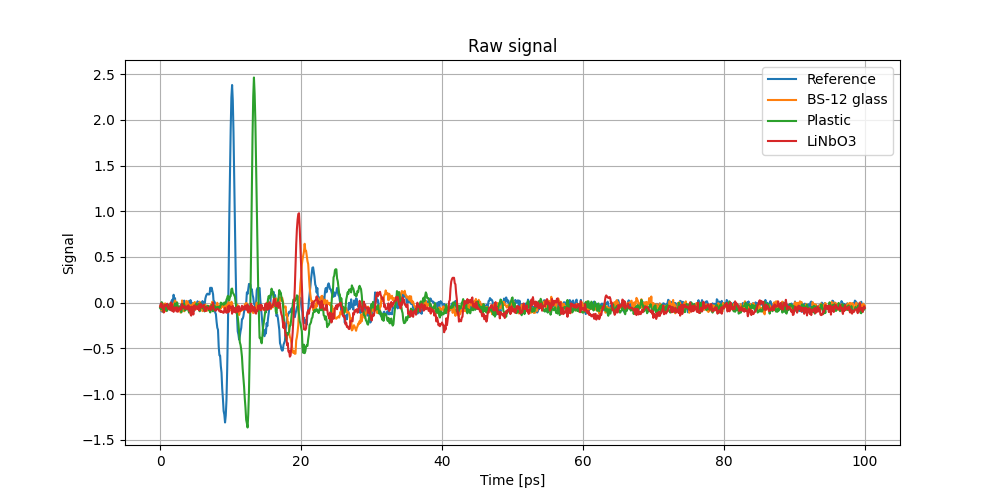

In [47]:
fig1 = plt.figure(figsize=(10,5))

ax1 = fig1.add_subplot(111)
ax1.set_title(r'Raw signal')
ax1.plot(time_ps, signal_ref, label="Reference")
ax1.plot(time_ps, signal_glass, label="BS-12 glass")
ax1.plot(time_ps, signal_plastic, label="Plastic")
ax1.plot(time_ps, signal_linbo3, label="LiNbO3")
ax1.set_xlabel('Time [ps]')
ax1.set_ylabel('Signal')
ax1.grid()
ax1.legend()

In [48]:
f_max_thz = 1/(2 * (time_ps[1] - time_ps[0]))

freqs_thz = np.linspace(-f_max_thz, f_max_thz, time_ps.shape[0])

spec_ref = np.fft.fftshift(np.fft.fft(signal_ref, norm='ortho'))
spec_glass = np.fft.fftshift(np.fft.fft(signal_glass, norm='ortho'))
spec_plastic = np.fft.fftshift(np.fft.fft(signal_plastic, norm='ortho'))
spec_linbo3 = np.fft.fftshift(np.fft.fft(signal_linbo3, norm='ortho'))

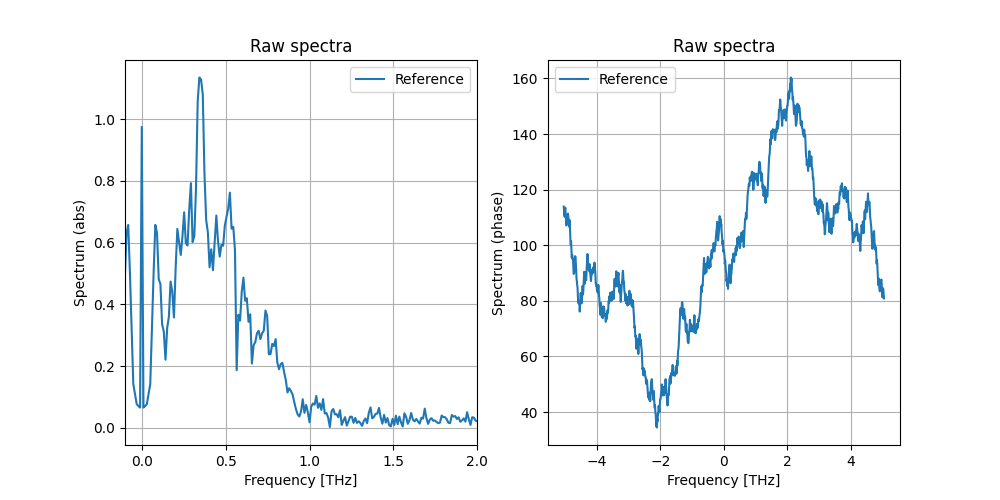

In [49]:
fig2 = plt.figure(figsize=(10,5))

ax1 = fig2.add_subplot(121)
ax1.set_title(r'Raw spectra')
ax1.plot(freqs_thz, np.abs(spec_ref), label="Reference")
# ax1.plot(freqs_thz, np.abs(spec_glass), label="BS-12 glass")
# ax1.plot(freqs_thz, np.abs(spec_plastic), label="Plastic")
# ax1.plot(freqs_thz, np.abs(spec_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

ax1 = fig2.add_subplot(122)
ax1.set_title(r'Raw spectra')
ax1.plot(freqs_thz, np.unwrap(np.angle(spec_ref, deg=True)), label="Reference")
# ax1.plot(freqs_thz, np.angle(spec_glass, deg=True), label="BS-12 glass")
# ax1.plot(freqs_thz, np.angle(spec_plastic, deg=True), label="Plastic")
# ax1.plot(freqs_thz, np.angle(spec_linbo3, deg=True), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
# ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

### Pre-processing

In [50]:
def super_gauss(time_arr: np.ndarray, tmin: float, tmax: float, p: int = 20):
    sigma = (tmax - tmin) / 2
    t0 = (tmax + tmin) / 2
    return np.exp(-((time_arr - t0)**2 / (2 * sigma**2))**p)

In [51]:
avg_len_ref = 60
avg_len_glass = 150
avg_len_plastic = 80
avg_len_linbo3 = 150

tmin_ref = 6
tmax_ref = 12

tmin_glass = 17
tmax_glass = 21

tmin_plastic = 9
tmax_plastic = 14

tmin_linbo3 = 17
tmax_linbo3 = 21

In [52]:
new_signal_ref = super_gauss(time_arr=time_ps, tmin=tmin_ref, tmax=tmax_ref) * (signal_ref - np.mean(signal_ref[:avg_len_ref]))
new_signal_glass =super_gauss(time_arr=time_ps, tmin=tmin_glass, tmax=tmax_glass) * (signal_glass - np.mean(signal_glass[:avg_len_glass]))
new_signal_plastic = super_gauss(time_arr=time_ps, tmin=tmin_plastic, tmax=tmax_plastic) * (signal_plastic - np.mean(signal_plastic[:avg_len_plastic]))
new_signal_linbo3 = super_gauss(time_arr=time_ps, tmin=tmin_linbo3, tmax=tmax_linbo3) * (signal_linbo3 - np.mean(signal_linbo3[:avg_len_linbo3]))

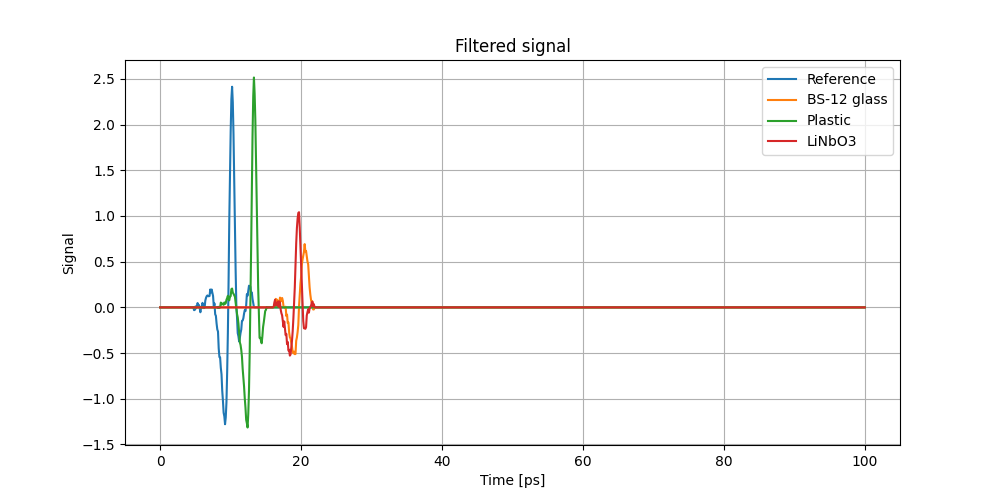

In [53]:
fig3 = plt.figure(figsize=(10,5))

ax1 = fig3.add_subplot(111)
ax1.set_title(r'Filtered signal')
ax1.plot(time_ps, new_signal_ref, label="Reference")
ax1.plot(time_ps, new_signal_glass, label="BS-12 glass")
ax1.plot(time_ps, new_signal_plastic, label="Plastic")
ax1.plot(time_ps, new_signal_linbo3, label="LiNbO3")
ax1.set_xlabel('Time [ps]')
ax1.set_ylabel('Signal')
ax1.grid()
ax1.legend()

### Fourier Transform

In [54]:
f_max_thz = 1/(2 * (time_ps[1] - time_ps[0]))

freqs_thz = np.linspace(0, f_max_thz, time_ps.shape[0] // 2)

new_spec_ref = (np.fft.fft(new_signal_ref, norm='ortho'))[:time_ps.shape[0] // 2]
new_spec_glass = (np.fft.fft(new_signal_glass, norm='ortho'))[:time_ps.shape[0] // 2]
new_spec_plastic = (np.fft.fft(new_signal_plastic, norm='ortho'))[:time_ps.shape[0] // 2]
new_spec_linbo3 = (np.fft.fft(new_signal_linbo3, norm='ortho'))[:time_ps.shape[0] // 2]

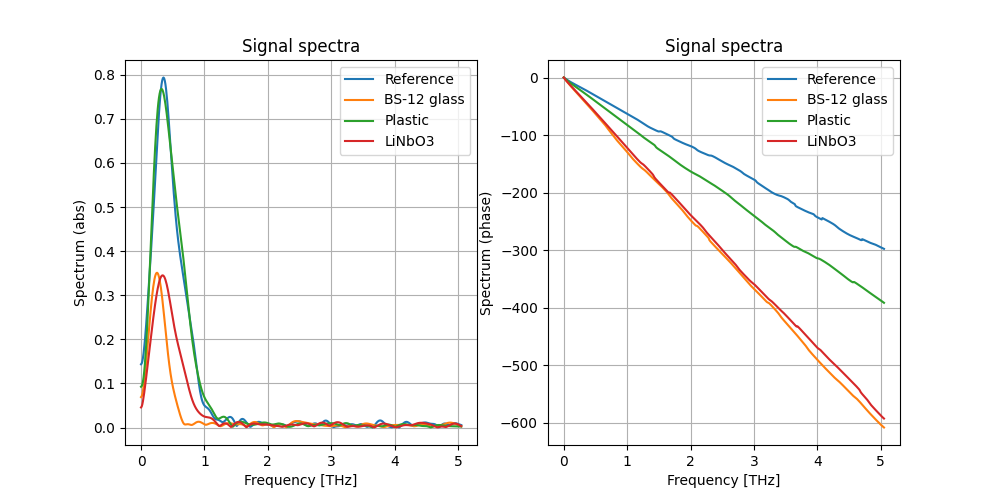

In [55]:
fig4 = plt.figure(figsize=(10,5))

ax1 = fig4.add_subplot(121)
ax1.set_title(r'Signal spectra')
# ax1.plot(freqs_thz, np.abs(new_spec_ref), label="Reference")
# ax1.plot(freqs_thz, np.abs(new_spec_glass), label="BS-12 glass")
# ax1.plot(freqs_thz, np.abs(new_spec_plastic), label="Plastic")
# ax1.plot(freqs_thz, np.abs(new_spec_linbo3), label="LiNbO3")
ax1.plot(freqs_thz, np.abs(new_spec_ref), label="Reference")
ax1.plot(freqs_thz, np.abs(new_spec_glass), label="BS-12 glass")
ax1.plot(freqs_thz, np.abs(new_spec_plastic), label="Plastic")
ax1.plot(freqs_thz, np.abs(new_spec_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
# ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

ax1 = fig4.add_subplot(122)
ax1.set_title(r'Signal spectra')
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_ref, deg=False)), label="Reference")
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_glass, deg=False)), label="BS-12 glass")
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_plastic, deg=False)), label="Plastic")
ax1.plot(freqs_thz, np.unwrap(np.angle(new_spec_linbo3, deg=False)), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
# ax1.set_xlim(left=-0.1, right=2.0)
ax1.grid()
ax1.legend()

In [56]:
from scipy.stats import linregress

def approx_phase(in_array: np.ndarray, left_bound_thz, right_bound_thz, final_up_thz_bound):
    f_max_thz = 1/(time_ps[1] - time_ps[0])
    delta_f = f_max_thz / in_array.shape[0]
    left_n = np.ceil(left_bound_thz / delta_f)
    right_n = np.floor(right_bound_thz / delta_f)
    new_arr = np.unwrap(np.angle(in_array[left_n:right_n], deg=True))

    res = linregress(np.arange(left_n, right_n, 1), new_arr)

    new_left_n = 0 / delta_f
    new_right_n = final_up_thz_bound / delta_f
    x = np.arange(new_left_n, new_right_n, 1)

    new_arr[new_left_n:new_right_n] = res.intercept + res.slope*x
    return new_arr

In [57]:
f_max_lin_thz = 1.2
n_f_max_lin = int(f_max_lin_thz / (f_max_thz / freqs_thz.shape[0]))

cut_freqs_thz = freqs_thz[:n_f_max_lin]
cut_spec_ref = new_spec_ref[:n_f_max_lin]
cut_spec_glass = new_spec_glass[:n_f_max_lin]
cut_spec_plastic = new_spec_plastic[:n_f_max_lin]
cut_spec_linbo3 = new_spec_linbo3[:n_f_max_lin]

### Refractive index calculation

In [58]:
h_glass_phase = np.unwrap(np.angle(cut_spec_glass, deg=False)) - np.unwrap(np.angle(cut_spec_ref, deg=False))
h_plastic_phase = np.unwrap(np.angle(cut_spec_plastic, deg=False)) - np.unwrap(np.angle(cut_spec_ref, deg=False))
h_linbo3_phase = np.unwrap(np.angle(cut_spec_linbo3, deg=False)) - np.unwrap(np.angle(cut_spec_ref, deg=False))

In [59]:
h_glass_abs = np.abs(cut_spec_glass / cut_spec_ref)
h_plastic_abs = np.abs(cut_spec_plastic / cut_spec_ref)
h_linbo3_abs = np.abs(cut_spec_linbo3 / cut_spec_ref)

C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_67096\2950014268.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig5 = plt.figure(figsize=(10,5))


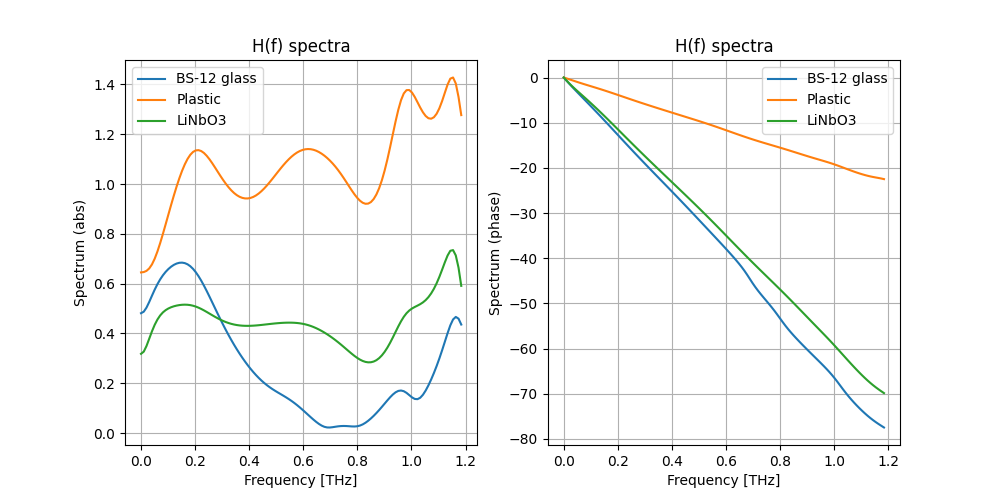

In [60]:
fig5 = plt.figure(figsize=(10,5))

ax1 = fig5.add_subplot(121)
ax1.set_title(r'H(f) spectra')
ax1.plot(cut_freqs_thz, h_glass_abs, label="BS-12 glass")
ax1.plot(cut_freqs_thz, h_plastic_abs, label="Plastic")
ax1.plot(cut_freqs_thz, h_linbo3_abs, label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.grid()
ax1.legend()

ax1 = fig5.add_subplot(122)
ax1.set_title(r'H(f) spectra')
ax1.plot(cut_freqs_thz, h_glass_phase, label="BS-12 glass")
ax1.plot(cut_freqs_thz, h_plastic_phase, label="Plastic")
ax1.plot(cut_freqs_thz, h_linbo3_phase, label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
ax1.grid()
ax1.legend()

In [61]:
line_glass = linregress(np.arange(0, cut_freqs_thz.shape[0], 1), h_glass_phase)
line_plastic = linregress(np.arange(0, cut_freqs_thz.shape[0], 1), h_plastic_phase)
line_linbo3 = linregress(np.arange(0, cut_freqs_thz.shape[0], 1), h_linbo3_phase)

h_glass_phase_appr = line_glass.slope * np.arange(0, cut_freqs_thz.shape[0], 1)
h_plastic_phase_appr = line_plastic.slope * np.arange(0, cut_freqs_thz.shape[0], 1)
h_linbo3_phase_appr = line_linbo3.slope * np.arange(0, cut_freqs_thz.shape[0], 1)

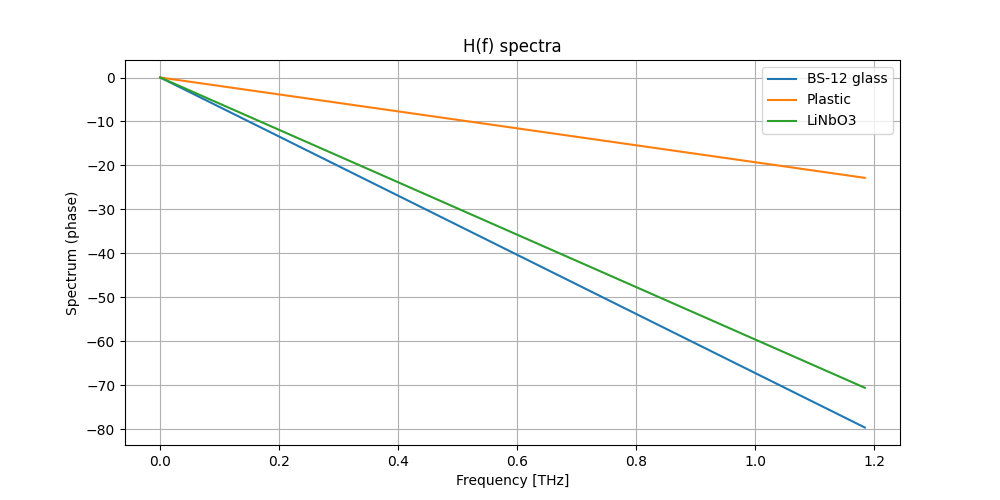

In [62]:
fig6 = plt.figure(figsize=(10,5))

ax1 = fig6.add_subplot(111)
ax1.set_title(r'H(f) spectra')
ax1.plot(cut_freqs_thz, h_glass_phase_appr, label="BS-12 glass")
ax1.plot(cut_freqs_thz, h_plastic_phase_appr, label="Plastic")
ax1.plot(cut_freqs_thz, h_linbo3_phase_appr, label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (phase)')
ax1.grid()
ax1.legend()

In [63]:
n0 = 1
c = 3 * 10**8
omega = 2 * np.pi * cut_freqs_thz * 1e12

l_glass = 2.11 * 10**(-3)
l_plastic = 2.18 * 10**(-3)
l_linbo3 = 0.5 * 10**(-3)

ns_glass = n0 - h_glass_phase_appr * c / (omega * l_glass)
ns_plastic = n0 - h_plastic_phase_appr * c / (omega * l_plastic)
ns_linbo3 = n0 - h_linbo3_phase_appr * c / (omega * l_linbo3)

ks_glass = c / (omega * l_glass) * (np.log((4 * ns_glass * n0) / (ns_glass + n0)**2) - np.log(h_glass_abs))
ks_plastic = c / (omega * l_plastic) * (np.log((4 * ns_plastic * n0) / (ns_plastic + n0)**2) - np.log(h_plastic_abs))
ks_linbo3 = c / (omega * l_linbo3) * (np.log((4 * ns_linbo3 * n0) / (ns_linbo3 + n0)**2) - np.log(h_linbo3_abs))

C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_67096\970966401.py:9: RuntimeWarning: invalid value encountered in divide
  ns_glass = n0 - h_glass_phase_appr * c / (omega * l_glass)
C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_67096\970966401.py:10: RuntimeWarning: invalid value encountered in divide
  ns_plastic = n0 - h_plastic_phase_appr * c / (omega * l_plastic)
C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_67096\970966401.py:11: RuntimeWarning: invalid value encountered in divide
  ns_linbo3 = n0 - h_linbo3_phase_appr * c / (omega * l_linbo3)
C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_67096\970966401.py:13: RuntimeWarning: divide by zero encountered in divide
  ks_glass = c / (omega * l_glass) * (np.log((4 * ns_glass * n0) / (ns_glass + n0)**2) - np.log(h_glass_abs))
C:\Users\isvoropaev\AppData\Local\Temp\ipykernel_67096\970966401.py:14: RuntimeWarning: divide by zero encountered in divide
  ks_plastic = c / (omega * l_plastic) * (np.log((4 * ns_plastic * n0) / (ns_

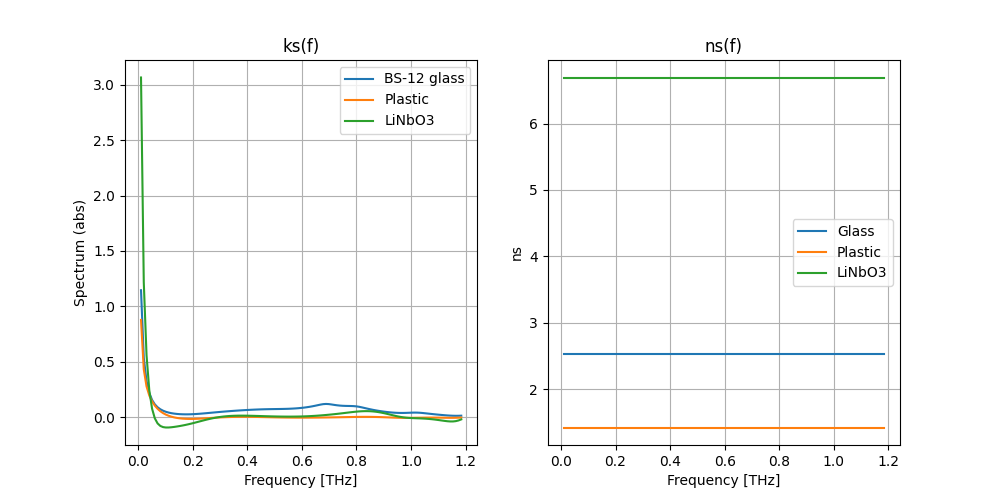

In [64]:
fig6 = plt.figure(figsize=(10,5))

ax1 = fig6.add_subplot(121)
ax1.set_title(r'ks(f)')
ax1.plot(cut_freqs_thz, ks_glass, label="BS-12 glass")
ax1.plot(cut_freqs_thz, ks_plastic, label="Plastic")
ax1.plot(cut_freqs_thz, ks_linbo3, label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.grid()
ax1.legend()

ax1 = fig6.add_subplot(122)
ax1.set_title(r'ns(f)')
ax1.plot(cut_freqs_thz, np.abs(ns_glass), label="Glass")
ax1.plot(cut_freqs_thz, np.abs(ns_plastic), label="Plastic")
ax1.plot(cut_freqs_thz, np.abs(ns_linbo3), label="LiNbO3")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('ns')
ax1.grid()
ax1.legend()

In [65]:
omega0 = 0.33 * 1e12
delta_t = (time_ps[1] - time_ps[0]) * 1e-12

ks_glass_bk_est = -np.log((np.max(new_signal_glass) / np.max(new_signal_ref))) * c / (omega0 * l_glass)
ks_plastic_bk_est = -np.log((np.max(new_signal_plastic) / np.max(new_signal_ref))) * c / (omega0 * l_plastic)
ks_linbo3_bk_est = -np.log((np.max(new_signal_linbo3) / np.max(new_signal_ref))) * c / (omega0 * l_linbo3)

ns_group_glass = (np.argmax(new_signal_glass) - np.argmax(new_signal_ref)) * delta_t * c / (2 * l_glass)
ns_group_plastic = (np.argmax(new_signal_plastic) - np.argmax(new_signal_ref)) * delta_t * c / (2 * l_plastic)
ns_group_linbo3 = (np.argmax(new_signal_linbo3) - np.argmax(new_signal_ref)) * delta_t * c / (2 * l_linbo3)

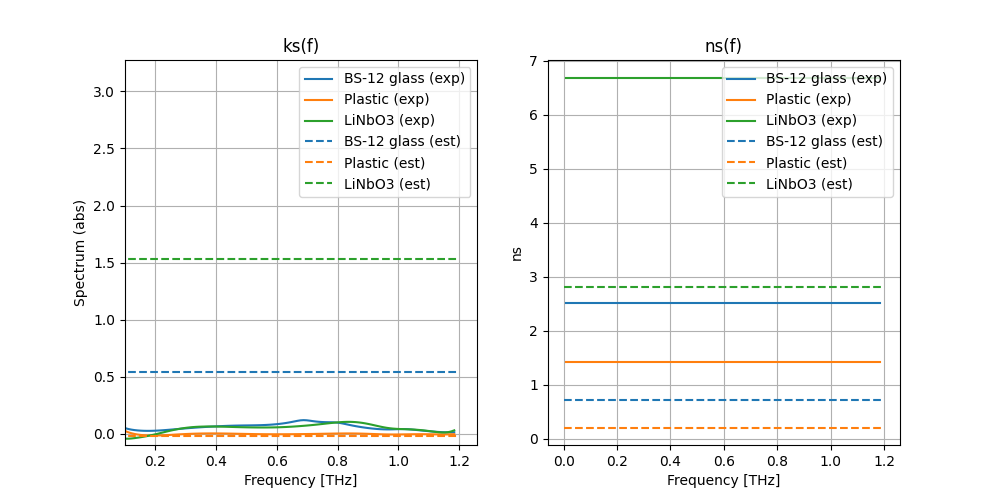

In [68]:
fig7 = plt.figure(figsize=(10,5))

ax1 = fig7.add_subplot(121)
ax1.set_title(r'ks(f)')
ax1.plot(cut_freqs_thz, ks_glass, label="BS-12 glass (exp)")
ax1.plot(cut_freqs_thz, ks_plastic, label="Plastic (exp)")
ax1.plot(cut_freqs_thz, ks_linbo3 + 0.05, label="LiNbO3 (exp)")
ax1.plot([0.0, 1.2], [ks_glass_bk_est, ks_glass_bk_est], "--", color="C0", label="BS-12 glass (est)")
ax1.plot([0.0, 1.2], [ks_plastic_bk_est, ks_plastic_bk_est], "--", color="C1", label="Plastic (est)")
ax1.plot([0.0, 1.2], [ks_linbo3_bk_est, ks_linbo3_bk_est], "--", color="C2", label="LiNbO3 (est)")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('Spectrum (abs)')
ax1.set_xlim(left=0.1)
ax1.set_ylim(bottom=-0.1)
ax1.grid()
ax1.legend()

ax1 = fig7.add_subplot(122)
ax1.set_title(r'ns(f)')
ax1.plot(cut_freqs_thz, ns_glass, label="BS-12 glass (exp)")
ax1.plot(cut_freqs_thz, ns_plastic, label="Plastic (exp)")
ax1.plot(cut_freqs_thz, ns_linbo3, label="LiNbO3 (exp)")
ax1.plot([0, 1.2], [ns_group_glass, ns_group_glass], "--", color="C0", label="BS-12 glass (est)")
ax1.plot([0, 1.2], [ns_group_plastic, ns_group_plastic], "--", color="C1", label="Plastic (est)")
ax1.plot([0, 1.2], [ns_group_linbo3, ns_group_linbo3], "--", color="C2", label="LiNbO3 (est)")
ax1.set_xlabel('Frequency [THz]')
ax1.set_ylabel('ns')
ax1.grid()
ax1.legend()